In [1]:
%load_ext autoreload
%autoreload 2


import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


In [23]:
import pandas as pd
from pathlib import Path

# Define the root directories
base_dirs = ['established', 'additional']

# List to hold all the individual DataFrames before concatenating
all_data = []

for base in base_dirs:
    base_path = Path('../../../sim_results/second_draft') / Path(base)
    
    if not base_path.exists():
        print(f"Directory '{base}' not found. Please ensure your notebook is in the correct root folder.")
        continue
        
    # rglob recursively searches for all CSVs ending in '_comprehensive_results.csv'
    for csv_file in base_path.rglob('*_comprehensive_results.csv'):
        
        # Extract metadata from the folder structure to keep track of where data came from
        # Structure: base / community_config / sim_folder / file.csv
        community_config = csv_file.parent.parent.name  # 'ground_truth', 'tau_0', or 'tau_2'
        sim_run = csv_file.parent.name                  # e.g., 'sim-results-2026-06-09_15-07-29_0000'
        
        try:
            # Read the CSV
            df = pd.read_csv(csv_file)
            
            # Inject folder metadata as new columns
            df['experiment_group'] = base               # 'established' or 'additional'
            df['community_config'] = community_config   # 'ground_truth', 'tau_0', 'tau_2'
            df['sim_run'] = sim_run                     # Keep track of the specific run
            
            all_data.append(df)
            
        except Exception as e:
            print(f"Failed to read {csv_file.name}: {e}")

# Combine everything into one master DataFrame
if all_data:
    master_df = pd.concat(all_data, ignore_index=True)
    
    print("✅ Data successfully loaded and merged!")
    print(f"Total rows: {len(master_df)}")
    
    # Quick sanity check for the split 'additional' strategies
    contact_school_mask = (master_df['dataset'] == 'contact-primary-school') & \
                          (master_df['experiment_group'] == 'additional') & \
                          (master_df['community_config'] == 'ground_truth')
    
    strategies_found = master_df[contact_school_mask]['strategy'].nunique()
    print(f"Strategies found for 'contact-primary-school' (additional/ground_truth): {strategies_found}")
    
else:
    print("❌ No data was loaded. Please check the directory paths.")
    master_df = pd.DataFrame()

# Preview the assembled data

master_df.head()




✅ Data successfully loaded and merged!
Total rows: 21060
Strategies found for 'contact-primary-school' (additional/ground_truth): 6


,dataset,p,strategy,K,remaining_nodes,timestep,mean_infected,experiment_group,community_config,sim_run
0,Algebra,0.05,EPT_TS,21,402.0,0,1.000000,established,ground_truth,sim-results-sim_paper_1-27195582950
1,Algebra,0.05,EPT_TS,21,402.0,1,1.447761,established,ground_truth,sim-results-sim_paper_1-27195582950
2,Algebra,0.05,EPT_TS,21,402.0,2,1.763433,established,ground_truth,sim-results-sim_paper_1-27195582950
3,Algebra,0.05,EPT_TS,21,402.0,3,2.148010,established,ground_truth,sim-results-sim_paper_1-27195582950
4,Algebra,0.05,EPT_TS,21,402.0,4,2.629602,established,ground_truth,sim-results-sim_paper_1-27195582950


In [29]:
from pathlib import Path

combined_path = Path("../../../sim_results/second_draft/combined.csv")
fin_df = master_df.drop(columns=["experiment_group", "sim_run"]).copy()
fin_df = fin_df[(fin_df["strategy"] != "EPT_ICS" ) & (fin_df["strategy"] != "aEPT_ICS") & (fin_df["strategy"] != "EPT_BPR") & (fin_df["strategy"] != "aEPT_BPR")].copy()
fin_df.to_csv(combined_path)

✅ Required columns found.

✅ Dataset filter applied.
Excluded dataset: contact-primary-school
Rows after filtering: 17550

✅ Final timestep data prepared.
Rows in final_df: 675

✅ Strategies ranked within each dataset, community_config, and p.
Important: infected percentages are not compared across datasets.


,dataset,community_config,p,strategy,mean_percent_infected_remaining,std_percent_infected_remaining,median_percent_infected_remaining,n_runs,mean_remaining_nodes,n_strategies_in_condition,raw_rank,normalized_rank_score
0,Algebra,ground_truth,0.05,aEPT_BIS,16.500334,NaN,16.500334,1,402.0,15,1.0,0.000000
1,Algebra,ground_truth,0.05,DEG,16.528551,NaN,16.528551,1,402.0,15,2.5,0.107143
2,Algebra,ground_truth,0.05,aDEG,16.528551,NaN,16.528551,1,402.0,15,2.5,0.107143
3,Algebra,ground_truth,0.05,EPT_TS,16.563946,NaN,16.563946,1,402.0,15,4.0,0.214286
4,Algebra,ground_truth,0.05,EPT_BIS,16.759486,NaN,16.759486,1,402.0,15,5.0,0.285714
5,Algebra,ground_truth,0.05,aEPT_TS,16.851254,NaN,16.851254,1,402.0,15,6.0,0.357143
6,Algebra,ground_truth,0.05,H_CD,17.506559,NaN,17.506559,1,402.0,15,7.0,0.428571
7,Algebra,ground_truth,0.05,aH_CD,17.633289,NaN,17.633289,1,402.0,15,8.0,0.500000
8,Algebra,ground_truth,0.05,HDEG,17.961251,NaN,17.961251,1,402.0,15,9.5,0.607143
9,Algebra,ground_truth,0.05,aHDEG,17.961251,NaN,17.961251,1,402.0,15,9.5,0.607143



STRATEGY COUNT PER CONDITION
If this varies, normalized rank score is safer than raw rank.


,dataset,community_config,p,n_strategies
0,Algebra,ground_truth,0.05,15
1,Algebra,ground_truth,0.10,15
2,Algebra,ground_truth,0.20,15
3,Algebra,tau_0,0.05,15
4,Algebra,tau_0,0.10,15
5,Algebra,tau_0,0.20,15
6,Algebra,tau_2,0.05,15
7,Algebra,tau_2,0.10,15
8,Algebra,tau_2,0.20,15
9,Bars-Rev,ground_truth,0.05,15



✅ Same number of strategies in every condition. Raw rank and normalized rank score are both acceptable.

FINAL STRATEGY RANKINGS PER COMMUNITY CONFIG
Rank-based only.
No infected percentages are averaged across datasets.
Lower normalized rank score is better.


COMMUNITY CONFIG: ground_truth
------------------------------------------------------------------------------------------
 1. aDEG                 Avg norm score:  0.164 | Median norm score:  0.143 | Avg raw rank:   3.30 | Best raw rank:   1.0 | Worst raw rank:   6.0 | Conditions: 15
 2. DEG                  Avg norm score:  0.193 | Median norm score:  0.143 | Avg raw rank:   3.70 | Best raw rank:   1.5 | Worst raw rank:   8.0 | Conditions: 15
 3. EPT_BIS              Avg norm score:  0.210 | Median norm score:  0.250 | Avg raw rank:   3.93 | Best raw rank:   1.0 | Worst raw rank:   7.0 | Conditions: 15
 4. aEPT_TS              Avg norm score:  0.221 | Median norm score:  0.143 | Avg raw rank:   4.10 | Best raw rank:   1.0 | Wo

,community_config,strategy,average_normalized_rank_score,median_normalized_rank_score,best_normalized_rank_score,worst_normalized_rank_score,average_raw_rank,median_raw_rank,best_raw_rank,worst_raw_rank,n_conditions,final_rank_within_config
0,ground_truth,aDEG,0.164286,0.142857,0.000000,0.357143,3.300000,3.0,1.0,6.0,15,1.0
1,ground_truth,DEG,0.192857,0.142857,0.035714,0.500000,3.700000,3.0,1.5,8.0,15,2.0
2,ground_truth,EPT_BIS,0.209524,0.250000,0.000000,0.428571,3.933333,4.5,1.0,7.0,15,3.0
3,ground_truth,aEPT_TS,0.221429,0.142857,0.000000,0.571429,4.100000,3.0,1.0,9.0,15,4.0
4,ground_truth,aEPT_BIS,0.285714,0.250000,0.000000,0.785714,5.000000,4.5,1.0,12.0,15,5.0
5,ground_truth,EPT_TS,0.359524,0.357143,0.071429,0.714286,6.033333,6.0,2.0,11.0,15,6.0
6,ground_truth,aH_CD,0.514286,0.500000,0.214286,0.785714,8.200000,8.0,4.0,12.0,15,7.0
7,ground_truth,aHDEG,0.521429,0.571429,0.142857,0.785714,8.300000,9.0,3.0,12.0,15,8.0
8,ground_truth,HDEG,0.550000,0.607143,0.214286,0.857143,8.700000,9.5,4.0,13.0,15,9.0
9,ground_truth,H_CD,0.595238,0.571429,0.285714,0.857143,9.333333,9.0,5.0,13.0,15,10.0



FINAL RANK CHANGES BETWEEN COMMUNITY CONFIGS
rank_range = max final rank - min final rank across community configs
rank_range = 0 means the strategy has the same final rank in every config


community_config,ground_truth,tau_0,tau_2,rank_range,rank_std
strategy,,,,,
aEPT_ICS,13.0,11.0,10.0,3.0,1.527525
H_CD,10.0,8.5,11.0,2.5,1.258306
EPT_BIS,3.0,5.0,5.0,2.0,1.154701
EPT_BPR,11.0,13.0,13.0,2.0,1.154701
EPT_ICS,14.0,12.0,12.0,2.0,1.154701
aEPT_BPR,12.0,14.0,14.0,2.0,1.154701
aH_CD,7.0,7.0,9.0,2.0,1.154701
HDEG,9.0,10.0,8.0,2.0,1.000000
aHDEG,8.0,8.5,7.0,1.5,0.763763


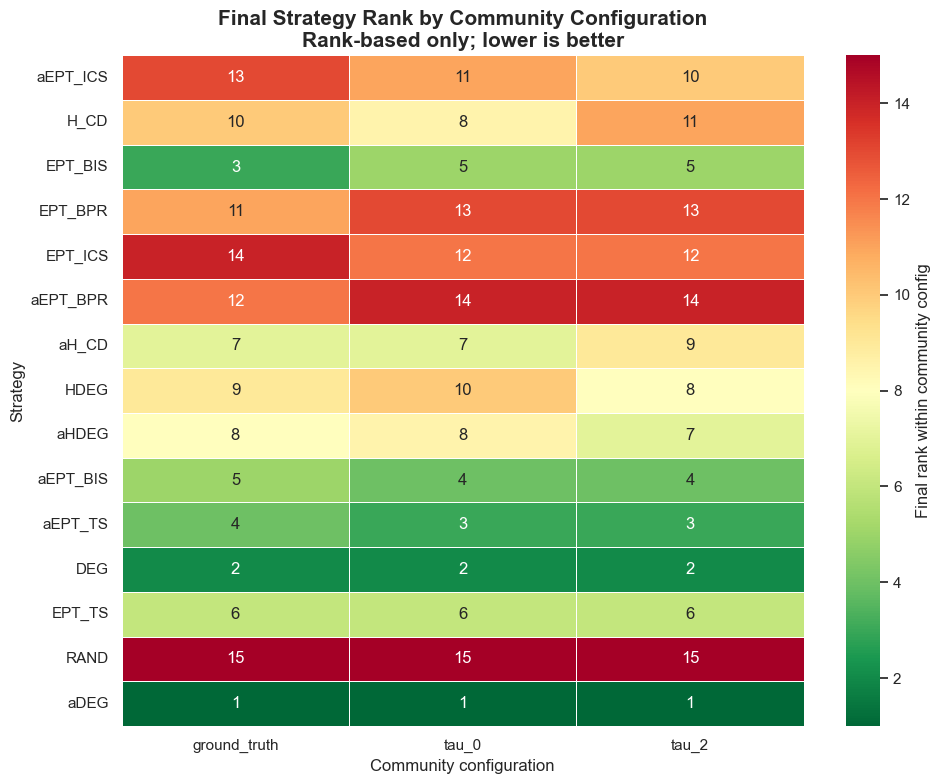

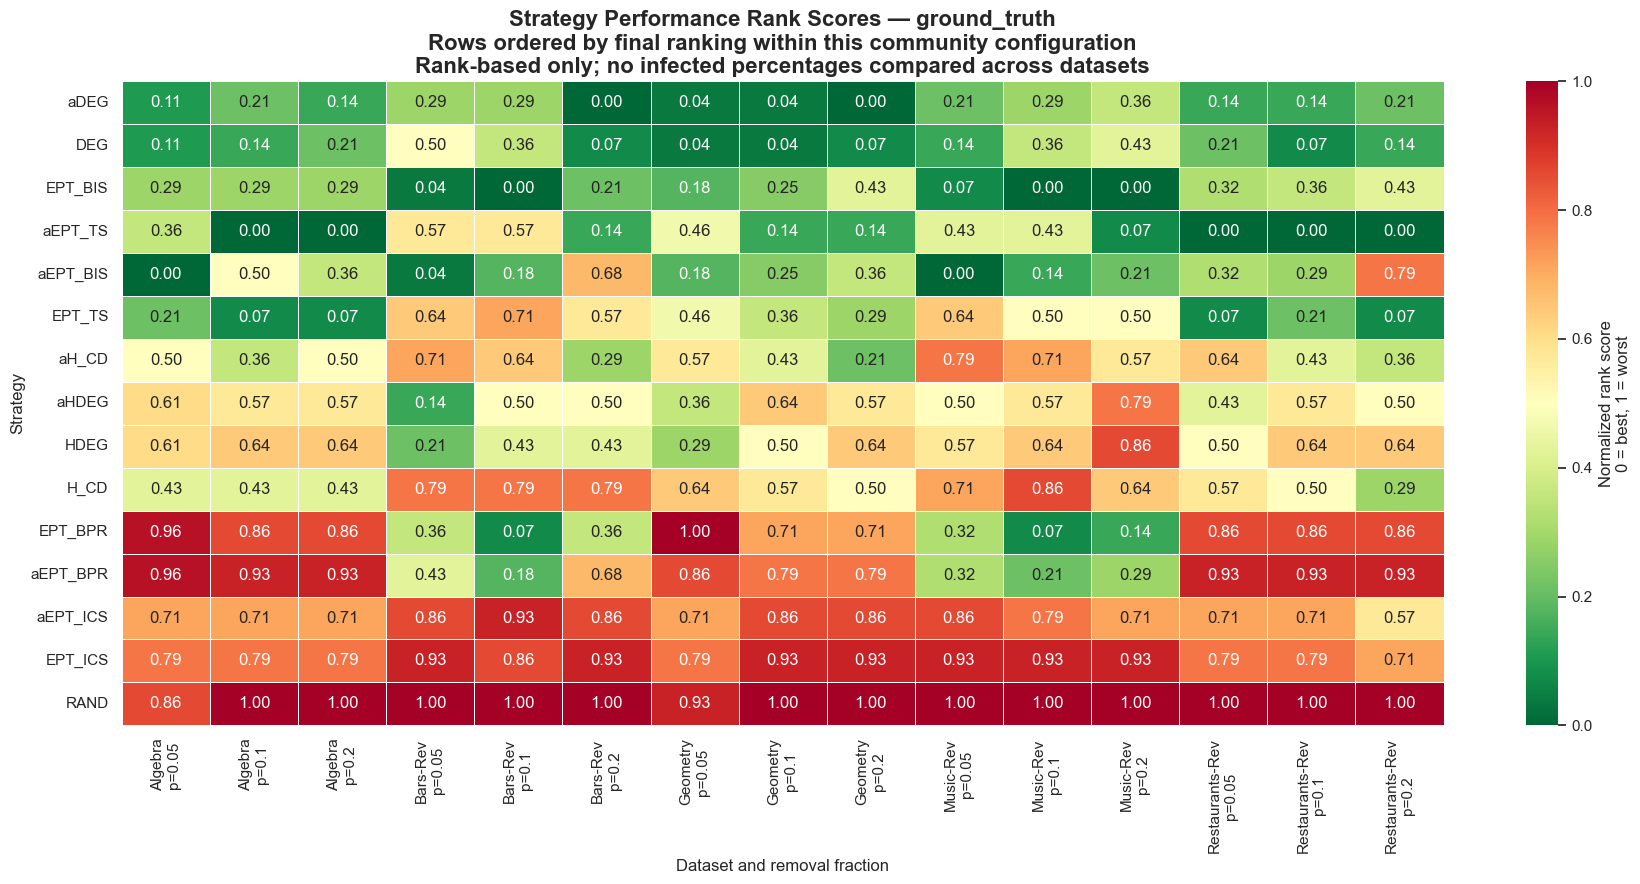

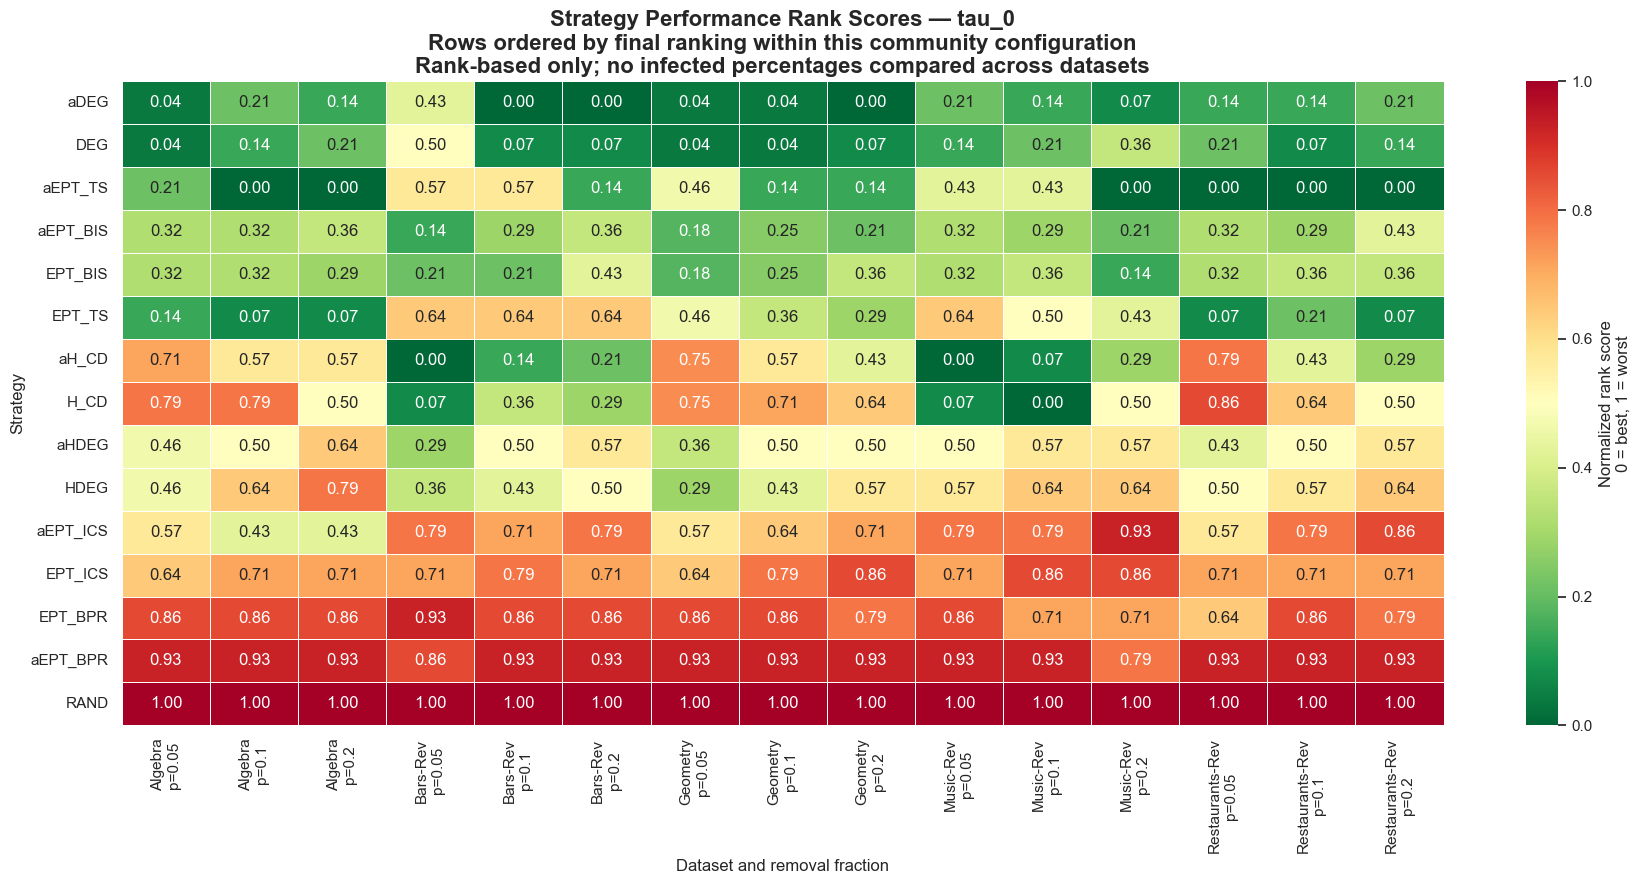

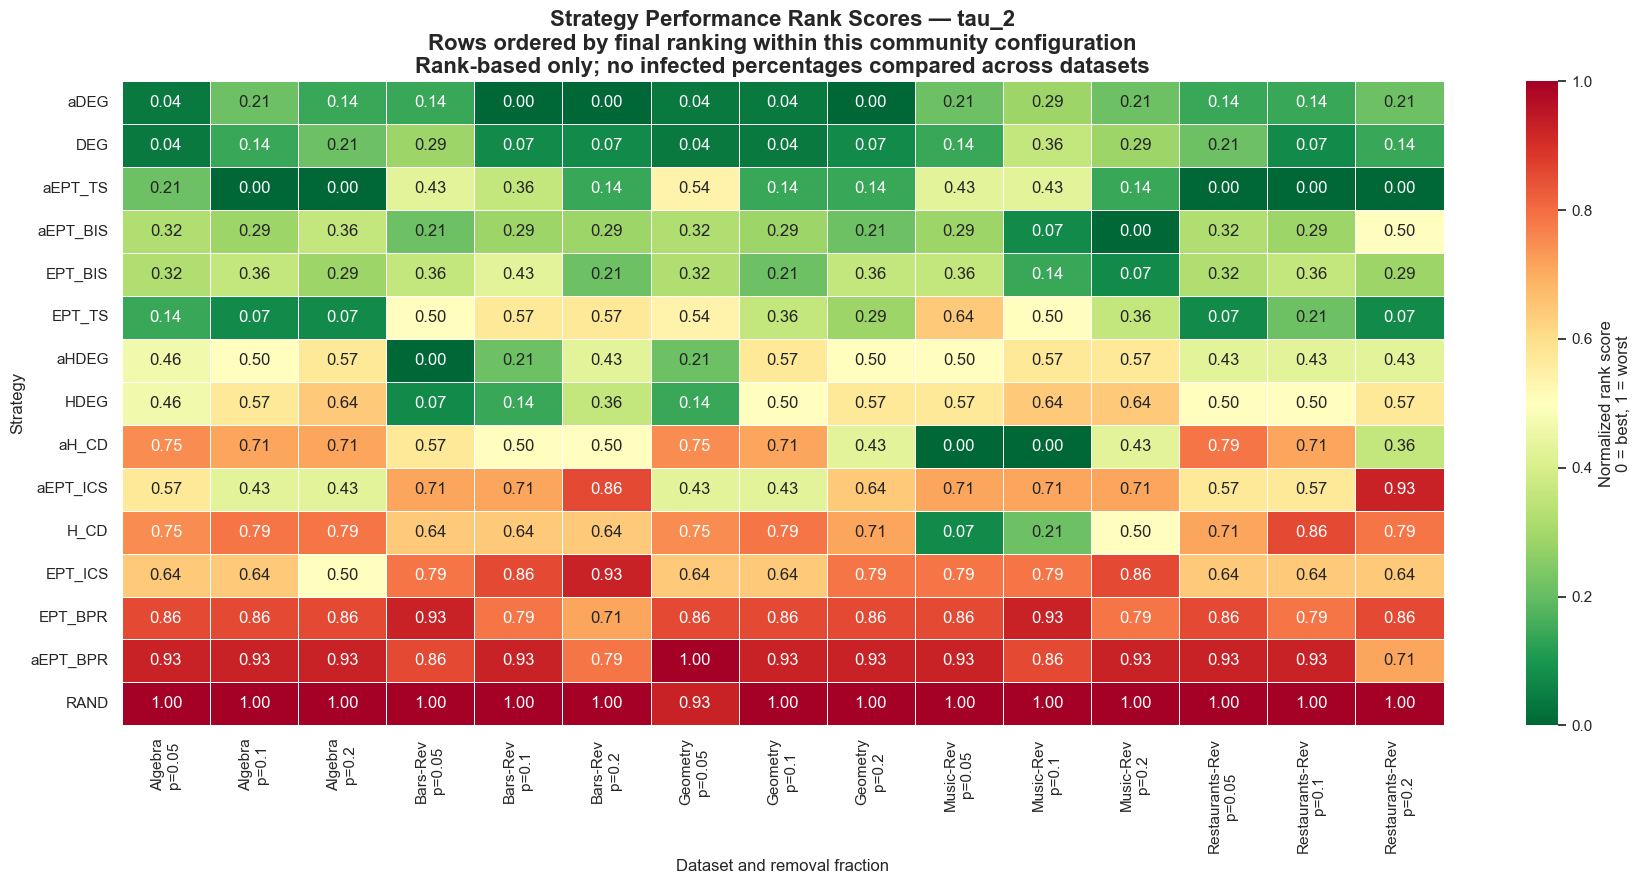


✅ Rank-score heatmaps created for each community_config.

FINAL STRATEGY RANKINGS PER COMMUNITY CONFIG AND p
Rank-based only.
This avoids summarizing across removal fractions.


,community_config,p,strategy,average_normalized_rank_score,median_normalized_rank_score,average_raw_rank,median_raw_rank,n_conditions,final_rank_within_config_p
0,ground_truth,0.05,aEPT_BIS,0.107143,0.035714,2.5,1.5,5,1.0
1,ground_truth,0.05,aDEG,0.157143,0.142857,3.2,3.0,5,2.0
2,ground_truth,0.05,EPT_BIS,0.178571,0.178571,3.5,3.5,5,3.0
3,ground_truth,0.05,DEG,0.200000,0.142857,3.8,3.0,5,4.0
4,ground_truth,0.05,aEPT_TS,0.364286,0.428571,6.1,7.0,5,5.0
...,...,...,...,...,...,...,...,...,...
130,tau_2,0.20,aEPT_ICS,0.714286,0.714286,11.0,11.0,5,11.0
131,tau_2,0.20,EPT_ICS,0.742857,0.785714,11.4,12.0,5,12.0
132,tau_2,0.20,EPT_BPR,0.814286,0.857143,12.4,13.0,5,13.0
133,tau_2,0.20,aEPT_BPR,0.857143,0.928571,13.0,14.0,5,14.0



OVERALL STRATEGY CONSISTENCY ACROSS ALL CONDITIONS
Rank-based only.
No infected percentages are averaged across datasets.


,strategy,average_normalized_rank_score,median_normalized_rank_score,best_normalized_rank_score,worst_normalized_rank_score,average_raw_rank,median_raw_rank,best_raw_rank,worst_raw_rank,n_conditions,overall_final_rank
0,aDEG,0.135714,0.142857,0.000000,0.428571,2.900000,3.0,1.0,7.0,45,1.0
1,DEG,0.164286,0.142857,0.035714,0.500000,3.300000,3.0,1.5,8.0,45,2.0
2,aEPT_TS,0.208730,0.142857,0.000000,0.571429,3.922222,3.0,1.0,9.0,45,3.0
3,EPT_BIS,0.265873,0.285714,0.000000,0.428571,4.722222,5.0,1.0,7.0,45,4.0
4,aEPT_BIS,0.280159,0.285714,0.000000,0.785714,4.922222,5.0,1.0,12.0,45,5.0
5,EPT_TS,0.346825,0.357143,0.071429,0.714286,5.855556,6.0,2.0,11.0,45,6.0
6,aH_CD,0.476984,0.500000,0.000000,0.785714,7.677778,8.0,1.0,12.0,45,7.0
7,aHDEG,0.481746,0.500000,0.000000,0.785714,7.744444,8.0,1.0,12.0,45,8.0
8,HDEG,0.515079,0.571429,0.071429,0.857143,8.211111,9.0,2.0,13.0,45,9.0
9,H_CD,0.578571,0.642857,0.000000,0.857143,9.100000,10.0,1.0,13.0,45,10.0


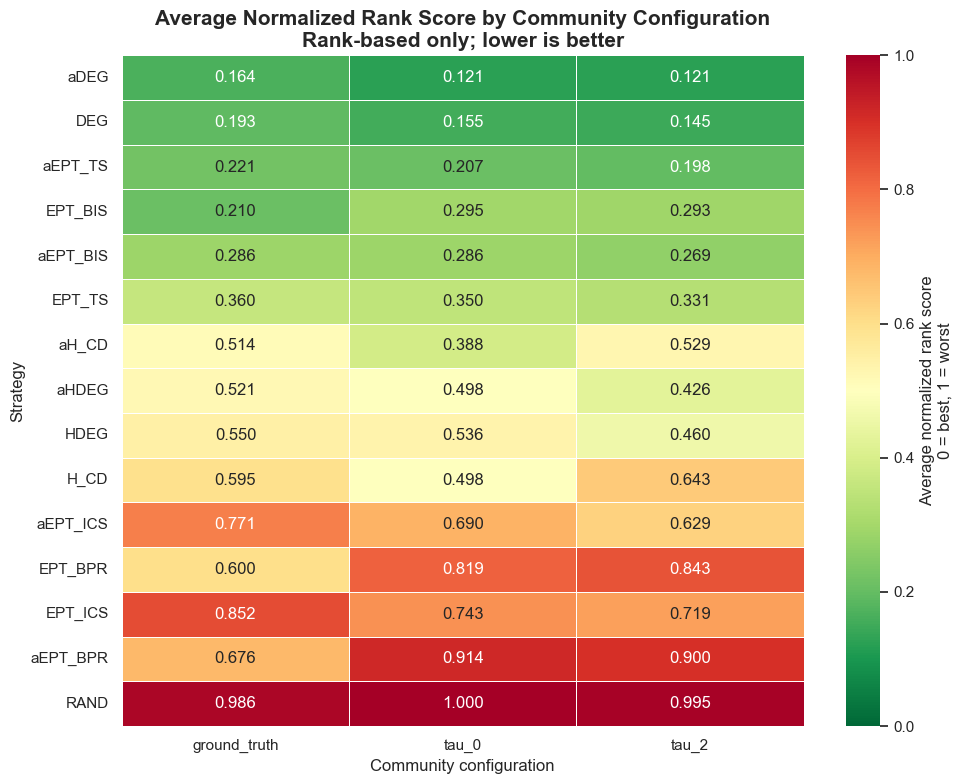


✅ Analysis complete.
No charts compare infected percentages across datasets.
All cross-dataset summaries are rank-based only.
Figures and CSV files saved in: infection_over_time_plots


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# SETTINGS
# =========================================================================

EXCLUDED_DATASET = "contact-primary-school"
OUTPUT_DIR = "infection_over_time_plots"

os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_theme(style="whitegrid")

# =========================================================================
# 1. BASIC VALIDATION
# =========================================================================

required_columns = [
    "dataset",
    "p",
    "strategy",
    "K",
    "remaining_nodes",
    "timestep",
    "mean_infected",
    "experiment_group",
    "community_config",
    "sim_run"
]

missing_columns = [
    col for col in required_columns
    if col not in master_df.columns
]

if len(missing_columns) > 0:
    raise ValueError(
        f"The following required columns are missing from master_df: {missing_columns}"
    )

print("✅ Required columns found.")

# =========================================================================
# 2. PREPARE DATA
# =========================================================================

df = master_df.copy()

# Exclude contact-primary-school from all analyses
df = df[df["dataset"] != EXCLUDED_DATASET].copy()

print("\n✅ Dataset filter applied.")
print(f"Excluded dataset: {EXCLUDED_DATASET}")
print(f"Rows after filtering: {len(df)}")

# Remove invalid denominator cases
invalid_remaining = df[df["remaining_nodes"] <= 0]

if len(invalid_remaining) > 0:
    print(
        f"\n⚠️ Warning: {len(invalid_remaining)} rows have remaining_nodes <= 0 "
        "and will be removed."
    )
    df = df[df["remaining_nodes"] > 0].copy()

# -------------------------------------------------------------------------
# Metric used ONLY for within-condition ranking:
#
# final infected percentage among remaining nodes
#
# This metric is NOT averaged across datasets for final conclusions.
# It is only used to determine which strategy performed better inside the
# same dataset, community_config, and p.
# -------------------------------------------------------------------------

df["percent_infected_remaining"] = (
    100 * df["mean_infected"] / df["remaining_nodes"]
)

# Optional reference column, not used for final cross-dataset summaries
df["original_nodes"] = df["K"] + df["remaining_nodes"]

df["percent_infected_original"] = (
    100 * df["mean_infected"] / df["original_nodes"]
)

# =========================================================================
# 3. KEEP ONLY FINAL TIMESTEP PER SIMULATION TRAJECTORY
# =========================================================================

idx = (
    df.groupby([
        "dataset",
        "community_config",
        "p",
        "strategy",
        "experiment_group",
        "sim_run"
    ])["timestep"]
    .idxmax()
)

final_df = df.loc[idx].copy()

print("\n✅ Final timestep data prepared.")
print(f"Rows in final_df: {len(final_df)}")

# =========================================================================
# 4. AGGREGATE STRATEGY PERFORMANCE WITHIN EACH CONDITION
# =========================================================================
# Valid comparison condition:
#
# dataset + community_config + p
#
# Percent infected is averaged over repeated simulation runs of the same
# condition and strategy. This is valid because the dataset, config, p,
# and strategy are fixed.
# =========================================================================

strategy_condition_perf = (
    final_df
    .groupby(["dataset", "community_config", "p", "strategy"])
    .agg(
        mean_percent_infected_remaining=("percent_infected_remaining", "mean"),
        std_percent_infected_remaining=("percent_infected_remaining", "std"),
        median_percent_infected_remaining=("percent_infected_remaining", "median"),
        n_runs=("percent_infected_remaining", "count"),
        mean_remaining_nodes=("remaining_nodes", "mean")
    )
    .reset_index()
)

# =========================================================================
# 5. RANK STRATEGIES ONLY WITHIN DATASET + COMMUNITY_CONFIG + p
# =========================================================================

# Count number of strategies in each valid comparison condition
strategy_condition_perf["n_strategies_in_condition"] = (
    strategy_condition_perf
    .groupby(["dataset", "community_config", "p"])["strategy"]
    .transform("nunique")
)

# Raw rank:
# 1 = best, higher = worse
strategy_condition_perf["raw_rank"] = (
    strategy_condition_perf
    .groupby(["dataset", "community_config", "p"])
    ["mean_percent_infected_remaining"]
    .rank(method="average", ascending=True)
)

# Normalized rank score:
# 0 = best
# 1 = worst
#
# This avoids problems if some conditions have different numbers of strategies.
strategy_condition_perf["normalized_rank_score"] = np.where(
    strategy_condition_perf["n_strategies_in_condition"] > 1,
    (
        strategy_condition_perf["raw_rank"] - 1
    ) / (
        strategy_condition_perf["n_strategies_in_condition"] - 1
    ),
    0.0
)

strategy_condition_perf = strategy_condition_perf.sort_values(
    ["community_config", "dataset", "p", "raw_rank"]
).reset_index(drop=True)

print("\n✅ Strategies ranked within each dataset, community_config, and p.")
print("Important: infected percentages are not compared across datasets.")

display(strategy_condition_perf.head(30))

strategy_condition_perf.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "strategy_condition_level_ranks_rank_based_only.csv"
    ),
    index=False
)

# =========================================================================
# 6. CHECK STRATEGY COUNT CONSISTENCY
# =========================================================================

condition_strategy_counts = (
    strategy_condition_perf
    .groupby(["dataset", "community_config", "p"])
    .agg(
        n_strategies=("strategy", "nunique")
    )
    .reset_index()
)

print("\n" + "=" * 90)
print("STRATEGY COUNT PER CONDITION")
print("If this varies, normalized rank score is safer than raw rank.")
print("=" * 90)

display(condition_strategy_counts)

condition_strategy_counts.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "strategy_counts_per_condition_rank_based_only.csv"
    ),
    index=False
)

if condition_strategy_counts["n_strategies"].nunique() > 1:
    print(
        "\n⚠️ Strategy count differs between conditions. "
        "Final summaries will use normalized rank score."
    )
else:
    print(
        "\n✅ Same number of strategies in every condition. "
        "Raw rank and normalized rank score are both acceptable."
    )

# =========================================================================
# 7. FINAL STRATEGY RANKINGS PER COMMUNITY CONFIG
# =========================================================================
# This is valid because it averages within-condition ranks, not infected
# percentages across datasets.
#
# It answers:
# Which strategy is most consistently strong within each community_config?
# =========================================================================

config_rankings = (
    strategy_condition_perf
    .groupby(["community_config", "strategy"])
    .agg(
        average_normalized_rank_score=("normalized_rank_score", "mean"),
        median_normalized_rank_score=("normalized_rank_score", "median"),
        best_normalized_rank_score=("normalized_rank_score", "min"),
        worst_normalized_rank_score=("normalized_rank_score", "max"),
        average_raw_rank=("raw_rank", "mean"),
        median_raw_rank=("raw_rank", "median"),
        best_raw_rank=("raw_rank", "min"),
        worst_raw_rank=("raw_rank", "max"),
        n_conditions=("normalized_rank_score", "count")
    )
    .reset_index()
)

config_rankings["final_rank_within_config"] = (
    config_rankings
    .groupby("community_config")["average_normalized_rank_score"]
    .rank(method="average", ascending=True)
)

config_rankings = config_rankings.sort_values(
    ["community_config", "final_rank_within_config"]
).reset_index(drop=True)

print("\n" + "=" * 90)
print("FINAL STRATEGY RANKINGS PER COMMUNITY CONFIG")
print("Rank-based only.")
print("No infected percentages are averaged across datasets.")
print("Lower normalized rank score is better.")
print("=" * 90)

for config in sorted(config_rankings["community_config"].unique()):
    print(f"\n\nCOMMUNITY CONFIG: {config}")
    print("-" * 90)

    config_df = (
        config_rankings[config_rankings["community_config"] == config]
        .sort_values("final_rank_within_config")
    )

    for row in config_df.itertuples(index=False):
        print(
            f"{int(row.final_rank_within_config):2d}. {row.strategy:<20} "
            f"Avg norm score: {row.average_normalized_rank_score:6.3f} "
            f"| Median norm score: {row.median_normalized_rank_score:6.3f} "
            f"| Avg raw rank: {row.average_raw_rank:6.2f} "
            f"| Best raw rank: {row.best_raw_rank:5.1f} "
            f"| Worst raw rank: {row.worst_raw_rank:5.1f} "
            f"| Conditions: {row.n_conditions}"
        )

display(config_rankings)

config_rankings.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_strategy_rankings_per_community_config_rank_based_only.csv"
    ),
    index=False
)

# =========================================================================
# 8. CHECK WHETHER FINAL RANKINGS CHANGE BETWEEN COMMUNITY CONFIGS
# =========================================================================

rank_comparison = config_rankings.pivot_table(
    index="strategy",
    columns="community_config",
    values="final_rank_within_config",
    aggfunc="mean"
)

rank_comparison["rank_range"] = (
    rank_comparison.max(axis=1) - rank_comparison.min(axis=1)
)

rank_comparison["rank_std"] = (
    rank_comparison
    .drop(columns=["rank_range"], errors="ignore")
    .std(axis=1)
)

rank_comparison = rank_comparison.sort_values(
    ["rank_range", "rank_std"],
    ascending=False
)

print("\n" + "=" * 90)
print("FINAL RANK CHANGES BETWEEN COMMUNITY CONFIGS")
print("rank_range = max final rank - min final rank across community configs")
print("rank_range = 0 means the strategy has the same final rank in every config")
print("=" * 90)

display(rank_comparison)

rank_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_rank_changes_between_community_configs_rank_based_only.csv"
    )
)

# =========================================================================
# 9. HEATMAP: FINAL RANK COMPARISON BETWEEN COMMUNITY CONFIGS
# =========================================================================
# Rank-based only.
# This does NOT compare infected percentages across datasets.
# =========================================================================

community_config_cols = [
    col for col in rank_comparison.columns
    if col not in ["rank_range", "rank_std"]
]

rank_comparison_plot = rank_comparison[community_config_cols].copy()

plt.figure(figsize=(10, 8))

sns.heatmap(
    rank_comparison_plot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={
        "label": "Final rank within community config"
    }
)

plt.title(
    "Final Strategy Rank by Community Configuration\n"
    "Rank-based only; lower is better",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Community configuration")
plt.ylabel("Strategy")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "final_strategy_rank_comparison_between_community_configs_rank_based_only.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================================
# 10. ONE NORMALIZED RANK-SCORE HEATMAP PER COMMUNITY CONFIG
# =========================================================================
# Each heatmap shows normalized rank score by dataset and p.
#
# 0 = best within that dataset/community_config/p
# 1 = worst within that dataset/community_config/p
#
# These are rank-based heatmaps, not infected-percentage heatmaps.
# =========================================================================

for config in sorted(strategy_condition_perf["community_config"].unique()):

    config_df = strategy_condition_perf[
        strategy_condition_perf["community_config"] == config
    ].copy()

    config_df["dataset_p"] = (
        config_df["dataset"].astype(str)
        + "\np="
        + config_df["p"].astype(str)
    )

    heatmap_rank_score = config_df.pivot_table(
        index="strategy",
        columns="dataset_p",
        values="normalized_rank_score",
        aggfunc="mean"
    )

    # Order rows by final ranking within this community_config
    config_strategy_order = (
        config_rankings[
            config_rankings["community_config"] == config
        ]
        .sort_values("final_rank_within_config")["strategy"]
        .tolist()
    )

    available_strategies = [
        strategy for strategy in config_strategy_order
        if strategy in heatmap_rank_score.index
    ]

    heatmap_rank_score = heatmap_rank_score.loc[available_strategies]

    plt.figure(figsize=(18, 9))

    sns.heatmap(
        heatmap_rank_score,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn_r",
        linewidths=0.5,
        vmin=0,
        vmax=1,
        cbar_kws={
            "label": "Normalized rank score\n0 = best, 1 = worst"
        }
    )

    plt.title(
        f"Strategy Performance Rank Scores — {config}\n"
        "Rows ordered by final ranking within this community configuration\n"
        "Rank-based only; no infected percentages compared across datasets",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Dataset and removal fraction")
    plt.ylabel("Strategy")

    plt.tight_layout()

    safe_config_name = (
        str(config)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"normalized_rank_score_heatmap_{safe_config_name}_rank_based_only.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("\n✅ Rank-score heatmaps created for each community_config.")

# =========================================================================
# 11. FINAL RANKINGS PER COMMUNITY CONFIG AND p
# =========================================================================
# This avoids summarizing across removal fractions.
#
# It answers:
# For each community_config and p, which strategy is most consistently good
# across datasets?
# =========================================================================

config_p_rankings = (
    strategy_condition_perf
    .groupby(["community_config", "p", "strategy"])
    .agg(
        average_normalized_rank_score=("normalized_rank_score", "mean"),
        median_normalized_rank_score=("normalized_rank_score", "median"),
        average_raw_rank=("raw_rank", "mean"),
        median_raw_rank=("raw_rank", "median"),
        n_conditions=("normalized_rank_score", "count")
    )
    .reset_index()
)

config_p_rankings["final_rank_within_config_p"] = (
    config_p_rankings
    .groupby(["community_config", "p"])["average_normalized_rank_score"]
    .rank(method="average", ascending=True)
)

config_p_rankings = config_p_rankings.sort_values(
    ["community_config", "p", "final_rank_within_config_p"]
).reset_index(drop=True)

print("\n" + "=" * 90)
print("FINAL STRATEGY RANKINGS PER COMMUNITY CONFIG AND p")
print("Rank-based only.")
print("This avoids summarizing across removal fractions.")
print("=" * 90)

display(config_p_rankings)

config_p_rankings.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_strategy_rankings_per_community_config_and_p_rank_based_only.csv"
    ),
    index=False
)

# =========================================================================
# 12. OPTIONAL OVERALL CONSISTENCY ACROSS ALL CONDITIONS
# =========================================================================
# This is still valid because it averages normalized ranks, not percentages.
#
# It answers:
# Which strategy is most consistently good across all valid conditions?
# =========================================================================

overall_consistency = (
    strategy_condition_perf
    .groupby("strategy")
    .agg(
        average_normalized_rank_score=("normalized_rank_score", "mean"),
        median_normalized_rank_score=("normalized_rank_score", "median"),
        best_normalized_rank_score=("normalized_rank_score", "min"),
        worst_normalized_rank_score=("normalized_rank_score", "max"),
        average_raw_rank=("raw_rank", "mean"),
        median_raw_rank=("raw_rank", "median"),
        best_raw_rank=("raw_rank", "min"),
        worst_raw_rank=("raw_rank", "max"),
        n_conditions=("normalized_rank_score", "count")
    )
    .reset_index()
)

overall_consistency["overall_final_rank"] = (
    overall_consistency["average_normalized_rank_score"]
    .rank(method="average", ascending=True)
)

overall_consistency = overall_consistency.sort_values(
    "overall_final_rank"
).reset_index(drop=True)

print("\n" + "=" * 90)
print("OVERALL STRATEGY CONSISTENCY ACROSS ALL CONDITIONS")
print("Rank-based only.")
print("No infected percentages are averaged across datasets.")
print("=" * 90)

display(overall_consistency)

overall_consistency.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "overall_strategy_consistency_rank_based_only.csv"
    ),
    index=False
)

# =========================================================================
# 13. HEATMAP: AVERAGE NORMALIZED RANK SCORE BY COMMUNITY CONFIG
# =========================================================================
# Rank-based only.
# This chart compares relative performance, not infection percentages.
# =========================================================================

config_score_comparison = config_rankings.pivot_table(
    index="strategy",
    columns="community_config",
    values="average_normalized_rank_score",
    aggfunc="mean"
)

# Order rows by overall consistency
overall_strategy_order = overall_consistency["strategy"].tolist()

available_strategies = [
    strategy for strategy in overall_strategy_order
    if strategy in config_score_comparison.index
]

config_score_comparison = config_score_comparison.loc[available_strategies]

plt.figure(figsize=(10, 8))

sns.heatmap(
    config_score_comparison,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={
        "label": "Average normalized rank score\n0 = best, 1 = worst"
    }
)

plt.title(
    "Average Normalized Rank Score by Community Configuration\n"
    "Rank-based only; lower is better",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Community configuration")
plt.ylabel("Strategy")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "average_normalized_rank_score_by_community_config_rank_based_only.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================================
# 14. FINAL MESSAGE
# =========================================================================

print("\n✅ Analysis complete.")
print("No charts compare infected percentages across datasets.")
print("All cross-dataset summaries are rank-based only.")
print(f"Figures and CSV files saved in: {OUTPUT_DIR}")